# Fund-by-Fund Spending Analysis with AI Replaceability Categories

This notebook analyzes Dallas ISD spending broken down by **fund number** — a critical dimension
because different funds represent different funding sources (general operating, federal grants,
bond funds, etc.) and each has distinct spending patterns and constraints.

## Steps
1. Load all data (transactions, pass1 categories, v2 research)
2. Re-extract fund codes from `raw_line` with validation
3. Profile all funds (spending, vendor count, date range)
4. Bar chart: top 15 funds by spending
5. Apply refined AI replaceability categories to all vendors
6. Build Fund × AI Category × Vendor pivot table
7. Heatmap: Fund (rows) × Category (columns) spending matrix
8. Deep dives: Fund 199 (General) and 6xx (Bond) series
9. Cross-reference with edtech_research_v2.json; identify research gaps
10. Export results to `data/fund_analysis/`

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from src.fund_analysis import (
    TEXAS_FUND_CODES, ALPHANUMERIC_FUND_CODES, FUND_CATEGORY_LABELS,
    AI_REPLACEABILITY_CATEGORIES,
    get_fund_info,
    extract_fund_code_from_raw_line, add_fund_codes_to_transactions,
    categorize_all_vendors_for_ai_analysis,
    profile_all_funds, build_fund_vendor_category_pivot,
    build_fund_summary_table,
    cross_reference_with_edtech_research,
    identify_unresearched_vendors_by_fund,
    export_fund_analysis,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 80)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

DATA_DIR = Path('../data')
print('Ready.')

Ready.


## Step 1 — Load all data

In [2]:
# Load raw transactions
transactions = pd.read_csv(DATA_DIR / 'extracted' / 'all_transactions_raw.csv')
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')
print(f'Transactions: {len(transactions):,} rows, ${transactions["amount"].sum():,.2f} total')

# Load pass1 vendor categorization
pass1 = pd.read_csv(DATA_DIR / 'vendors' / 'vendor_categorization_pass1.csv')
print(f'Pass1 vendors: {len(pass1):,}')

# Load v2 edtech research
v2_path = DATA_DIR / 'vendors' / 'edtech_research_v2.json'
with open(v2_path) as f:
    v2_research = json.load(f)
print(f'V2 research entries: {len(v2_research)}')

Transactions: 122,693 rows, $5,964,972,065.83 total
Pass1 vendors: 9,370
V2 research entries: 24


## Step 2 — Re-extract fund codes from `raw_line`

In [3]:
# Re-extract fund codes (the existing 'fund' column is unreliable)
transactions = add_fund_codes_to_transactions(transactions)

extracted = transactions['fund_code'].notna().sum()
total = len(transactions)
print(f'Fund code extraction: {extracted:,} / {total:,} ({extracted/total*100:.1f}%)')
print(f'Unmatched: {total - extracted:,}')

Fund code extraction: 122,693 / 122,693 (100.0%)
Unmatched: 0


In [4]:
# Spot-check: compare extracted fund_code vs original fund column
sample = transactions[['vendor', 'amount', 'fund', 'fund_code', 'fund_name', 'raw_line']].sample(15, random_state=42)
for _, row in sample.iterrows():
    match_str = 'OK' if str(row['fund']) == str(row['fund_code']) else 'FIXED'
    print(f'[{match_str:5s}] orig={str(row["fund"]):10s} new={str(row["fund_code"]):5s}  {row["vendor"][:40]}')

[FIXED] orig=Training   new=199    TORREGROSA VELEZ, MILITZA
[FIXED] orig=Comp       new=753    PHYLLIS M PAGE
[FIXED] orig=Contracted new=199    WALSH GALLEGOS TREVINO KYLE &
[FIXED] orig=Training   new=199    PECINA, NORMA L
[FIXED] orig=Gas        new=199    ATMOS ENERGY
[FIXED] orig=Sup        new=481    SCHOOL NURSE SUPPLY INC
[FIXED] orig=Contracted new=199    UNIVERSITY OF TEXAS AT DALLAS
[FIXED] orig=Training   new=199    UIL REGION 20
[FIXED] orig=Sup        new=199    LIMITLESS OFFICE PRODUCTS
[FIXED] orig=Sup        new=199    GALLS, LLC
[FIXED] orig=Parts      new=199    DALLAS COUNTY TAX COLLECTOR
[FIXED] orig=Contracted new=199    EXPRESS CHEER DBA SPIRIT ATHLETICS
[FIXED] orig=Svc-Supplies new=240    SANITECH SYSTEMS
[FIXED] orig=Repair     new=199    SOUTHWEST INTERNATIONAL TRUCK INC
[FIXED] orig=Sup        new=199    THE HOME DEPOT


In [5]:
# Fund code distribution
fund_counts = transactions['fund_code'].value_counts()
print(f'Unique fund codes: {len(fund_counts)}')
print()
print('Top 20 fund codes by transaction count:')
for code, count in fund_counts.head(20).items():
    info = get_fund_info(code)
    spending = transactions[transactions['fund_code'] == code]['amount'].sum()
    print(f'  {code:5s}  {count:6,d} txns  ${spending:>15,.2f}  {info["name"]}')

Unique fund codes: 83

Top 20 fund codes by transaction count:
  199    85,164 txns  $3,094,081,281.24  General Fund
  240     7,497 txns  $ 195,560,905.32  National School Lunch/Breakfast Program
  651     6,858 txns  $1,322,030,034.08  Bond Construction (2015 Election)
  753     5,826 txns  $  15,850,607.72  Workers Compensation
  282     4,291 txns  $ 181,795,450.36  ESSER II/III (ARP)
  211     3,223 txns  $  33,109,952.07  ESEA Title I, Part A
  637     3,162 txns  $ 545,076,033.73  Bond Construction (2020 Election)
  652       839 txns  $ 144,565,351.80  Bond Construction (652)
  263       741 txns  $   8,684,537.74  Title III, Part A
  255       632 txns  $   3,703,399.68  Title II, Part A
  752       596 txns  $   4,957,568.37  Self-Insurance (752)
  180       478 txns  $  10,932,480.21  State/Local Special Revenue
  653       450 txns  $  66,923,988.83  Bond Construction (653)
  481       365 txns  $   3,473,377.00  Capital Projects (481)
  28B       253 txns  $   6,156,327.92

## Step 3 — Profile all funds

In [6]:
# We need vendor AI categories first (basic pass1 mapping for profiling)
# Full AI categorization happens in Step 5, but we need a basic version here
vendor_cats = categorize_all_vendors_for_ai_analysis(pass1, str(v2_path))
print(f'Categorized {len(vendor_cats):,} vendors into AI replaceability categories')
print()
print('AI Category distribution (by vendor count):')
print(vendor_cats['ai_category'].value_counts().to_string())

Categorized 9,370 vendors into AI replaceability categories

AI Category distribution (by vendor count):
ai_category
other                      8866
supplemental_edtech         154
food_transportation          92
construction_facilities      74
professional_services        61
it_hardware                  60
payroll_benefits             22
assessment_testing           13
curriculum_digital           12
adaptive_learning             7
textbooks_publishing          5
library_media                 1
sis_data_compliance           1
it_software_infra             1
lms_classroom                 1


In [7]:
# Profile all funds
fund_profiles = profile_all_funds(transactions, vendor_cats)
fund_summary = build_fund_summary_table(fund_profiles)

print(f'Profiled {len(fund_profiles)} funds\n')
print('Fund Summary (top 20 by spending):')
print('=' * 110)
for _, row in fund_summary.head(20).iterrows():
    pct = row['total_spending'] / fund_summary['total_spending'].sum() * 100
    ai_pct = row['ai_replaceable_pct']
    print(
        f'{row["fund_code"]:5s}  '
        f'{row["fund_name"][:40]:40s}  '
        f'${row["total_spending"]:>14,.0f}  '
        f'{pct:5.1f}%  '
        f'{row["vendor_count"]:5,d} vendors  '
        f'AI-repl: {ai_pct:4.1f}%'
    )

Profiled 83 funds

Fund Summary (top 20 by spending):
199    General Fund                              $ 3,094,081,281   51.9%  7,452 vendors  AI-repl:  1.6%
651    Bond Construction (2015 Election)         $ 1,322,030,034   22.2%    339 vendors  AI-repl:  0.4%
637    Bond Construction (2020 Election)         $   545,076,034    9.1%    209 vendors  AI-repl:  0.1%
240    National School Lunch/Breakfast Program   $   195,560,905    3.3%    395 vendors  AI-repl:  0.0%
282    ESSER II/III (ARP)                        $   181,795,450    3.0%    943 vendors  AI-repl: 29.4%
652    Bond Construction (652)                   $   144,565,352    2.4%     65 vendors  AI-repl:  1.5%
640    Bond Construction (640)                   $   102,483,362    1.7%     56 vendors  AI-repl:  0.0%
653    Bond Construction (653)                   $    66,923,989    1.1%     34 vendors  AI-repl:  0.0%
650    Bond Construction (650)                   $    50,231,839    0.8%     19 vendors  AI-repl:  0.0%
410    Deb

## Step 4 — Bar chart: top 15 funds by spending

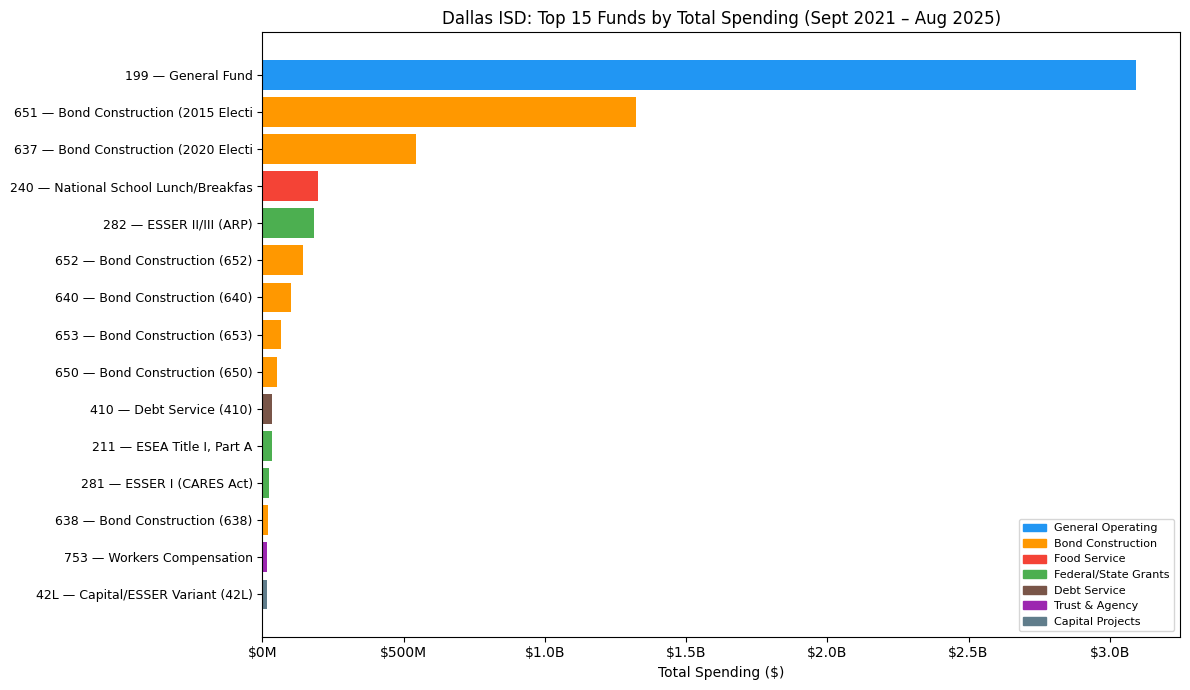

In [8]:
top15 = fund_summary.head(15).copy()
top15['label'] = top15['fund_code'] + ' — ' + top15['fund_name'].str[:30]

fig, ax = plt.subplots(figsize=(12, 7))
colors = []
cat_colors = {
    'general_operating': '#2196F3',
    'federal_state_grants': '#4CAF50',
    'bond_construction': '#FF9800',
    'trust_agency': '#9C27B0',
    'food_service': '#F44336',
    'debt_service': '#795548',
    'capital_projects': '#607D8B',
    'internal': '#CDDC39',
}
for _, row in top15.iterrows():
    colors.append(cat_colors.get(row['fund_category'], '#999999'))

bars = ax.barh(range(len(top15)), top15['total_spending'], color=colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['label'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Total Spending ($)')
ax.set_title('Dallas ISD: Top 15 Funds by Total Spending (Sept 2021 – Aug 2025)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B' if x >= 1e9 else f'${x/1e6:.0f}M'))

# Legend
from matplotlib.patches import Patch
seen = set()
handles = []
for _, row in top15.iterrows():
    cat = row['fund_category']
    if cat not in seen:
        seen.add(cat)
        label = FUND_CATEGORY_LABELS.get(cat, cat)
        handles.append(Patch(color=cat_colors.get(cat, '#999'), label=label))
ax.legend(handles=handles, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## Step 5 — Apply refined AI replaceability categories

In [9]:
# vendor_cats was already computed in Step 3 — summarize by AI category
ai_summary = (
    vendor_cats.groupby('ai_category')
    .agg(vendors=('vendor', 'count'), spending=('total_spending', 'sum'))
    .sort_values('spending', ascending=False)
)
ai_summary['pct'] = ai_summary['spending'] / ai_summary['spending'].sum() * 100
ai_summary['ai_potential'] = ai_summary.index.map(
    lambda c: AI_REPLACEABILITY_CATEGORIES.get(c, {}).get('ai_potential', '?')
)

print('AI Replaceability Category Breakdown:')
print('=' * 95)
for cat, row in ai_summary.iterrows():
    cat_name = AI_REPLACEABILITY_CATEGORIES.get(cat, {}).get('name', cat)
    print(
        f'{row["ai_potential"]:6s}  '
        f'{cat_name:35s}  '
        f'{int(row["vendors"]):5d} vendors  '
        f'${row["spending"]:>14,.0f}  '
        f'{row["pct"]:5.1f}%'
    )

AI Replaceability Category Breakdown:
none    Other                                 8866 vendors  $ 2,536,603,856   42.5%
none    Payroll & Benefits                      22 vendors  $ 1,884,609,274   31.6%
none    Construction & Facilities               74 vendors  $   892,548,854   15.0%
none    IT Hardware                             60 vendors  $   286,300,560    4.8%
none    Food & Transportation                   92 vendors  $   146,668,127    2.5%
medium  Digital Curriculum                      12 vendors  $    96,808,386    1.6%
low     Professional Services                   61 vendors  $    53,265,694    0.9%
high    Supplemental EdTech                    154 vendors  $    46,421,151    0.8%
low     Library & Media                          1 vendors  $     6,957,355    0.1%
medium  Adaptive Learning Platforms              7 vendors  $     3,646,752    0.1%
high    Assessment & Testing                    13 vendors  $     2,904,099    0.0%
medium  SIS, Data & Compliance        

In [10]:
# Summarize by AI potential level
potential_summary = ai_summary.groupby('ai_potential').agg(
    vendors=('vendors', 'sum'),
    spending=('spending', 'sum'),
).sort_values('spending', ascending=False)
potential_summary['pct'] = potential_summary['spending'] / potential_summary['spending'].sum() * 100

print('\nSpending by AI Replaceability Potential:')
print('=' * 60)
for level, row in potential_summary.iterrows():
    print(
        f'{level:8s}  '
        f'{int(row["vendors"]):5d} vendors  '
        f'${row["spending"]:>14,.0f}  '
        f'{row["pct"]:5.1f}%'
    )


Spending by AI Replaceability Potential:
none       9114 vendors  $ 5,746,730,672   96.3%
medium       20 vendors  $   103,126,662    1.7%
low          68 vendors  $    65,085,282    1.1%
high        168 vendors  $    50,029,450    0.8%


## Step 6 — Build Fund × AI Category × Vendor pivot table

In [11]:
pivot = build_fund_vendor_category_pivot(transactions, vendor_cats)
print(f'Pivot table: {len(pivot):,} rows (fund_code × ai_category × vendor)')
print(f'Total spending in pivot: ${pivot["total_spending"].sum():,.2f}')
print()

# Show top entries
print('Top 15 fund-category-vendor combinations by spending:')
top_pivot = pivot.head(15).reset_index()
for _, row in top_pivot.iterrows():
    print(
        f'  {row["fund_code"]:5s}  '
        f'{row["ai_category"]:25s}  '
        f'{row["vendor"][:35]:35s}  '
        f'${row["total_spending"]:>14,.0f}  '
        f'{int(row["transaction_count"]):4d} txns'
    )

Pivot table: 12,053 rows (fund_code × ai_category × vendor)
Total spending in pivot: $5,964,972,065.83

Top 15 fund-category-vendor combinations by spending:
  199    payroll_benefits           TEACHER RETIREMENT SYSTEM OF TEXAS   $ 1,165,716,922   104 txns
  199    payroll_benefits           INTERNAL REVENUE SERVICE             $   586,455,575   399 txns
  651    other                      RATCLIFF CONSTRUCTORS LP             $   188,558,440   107 txns
  651    construction_facilities    BECK 3I JOINT VENTURE                $   125,518,983    42 txns
  637    construction_facilities    REEDER GENERAL CONTRACTORS, INC.     $   103,311,090   100 txns
  199    construction_facilities    RELIANT ENERGY RETAIL SERVICES LLC   $   100,926,994   184 txns
  651    construction_facilities    SFP2, A JOINT VENTURE, LLC           $    94,410,260    38 txns
  651    other                      SEDALCO, INC.                        $    84,884,534    57 txns
  640    construction_facilities    HC BEC

## Step 7 — Heatmap: Fund × Category spending matrix

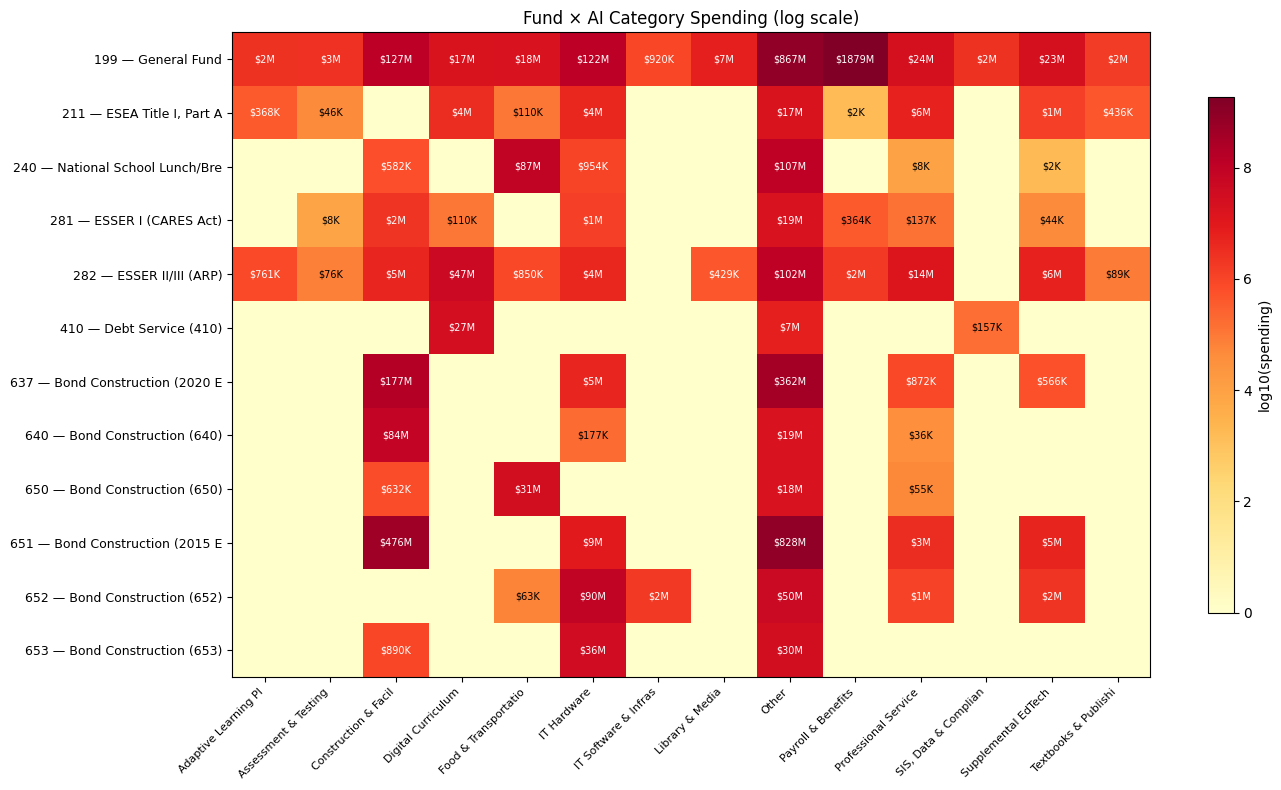

In [12]:
# Build fund × category matrix for top funds
pivot_flat = pivot.reset_index()
top_fund_codes = fund_summary.head(12)['fund_code'].tolist()

matrix_data = (
    pivot_flat[pivot_flat['fund_code'].isin(top_fund_codes)]
    .groupby(['fund_code', 'ai_category'])['total_spending']
    .sum()
    .unstack(fill_value=0)
)

# Only keep categories with meaningful spending
col_totals = matrix_data.sum()
keep_cols = col_totals[col_totals > 1_000_000].index.tolist()
matrix_data = matrix_data[keep_cols]

# Pretty column names
col_labels = [AI_REPLACEABILITY_CATEGORIES.get(c, {}).get('name', c)[:20] for c in keep_cols]

# Add fund names to index
fund_labels = [f'{c} — {get_fund_info(c)["name"][:25]}' for c in matrix_data.index]

fig, ax = plt.subplots(figsize=(14, 8))
log_data = np.log10(matrix_data.values + 1)
im = ax.imshow(log_data, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(fund_labels)))
ax.set_yticklabels(fund_labels, fontsize=9)
ax.set_title('Fund × AI Category Spending (log scale)', fontsize=12)

# Annotate cells with dollar amounts
for i in range(len(fund_labels)):
    for j in range(len(col_labels)):
        val = matrix_data.values[i, j]
        if val > 0:
            label = f'${val/1e6:.0f}M' if val >= 1e6 else f'${val/1e3:.0f}K'
            color = 'white' if log_data[i, j] > log_data.max() * 0.6 else 'black'
            ax.text(j, i, label, ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='log10(spending)', shrink=0.8)
plt.tight_layout()
plt.show()

## Step 8 — Deep dives: Fund 199 (General) and 6xx (Bond) series

In [13]:
# Fund 199 deep dive
f199 = [p for p in fund_profiles if p.fund_code == '199'][0]

print('=' * 80)
print('FUND 199 — GENERAL FUND DEEP DIVE')
print('=' * 80)
print(f'Total spending:     ${f199.total_spending:>14,.2f}')
print(f'Transactions:       {f199.transaction_count:>14,d}')
print(f'Unique vendors:     {f199.vendor_count:>14,d}')
print(f'Date range:         {f199.date_range[0]} to {f199.date_range[1]}')
print(f'AI-replaceable $:   ${f199.ai_replaceable_spending:>14,.2f}')
print(f'AI-replaceable %:   {f199.ai_replaceable_spending / f199.total_spending * 100:>13.1f}%')
print()
print('Top 15 vendors in Fund 199:')
for vendor, spending in f199.top_vendors[:15]:
    pct = spending / f199.total_spending * 100
    print(f'  {vendor[:50]:50s}  ${spending:>14,.0f}  {pct:5.1f}%')
print()
print('Category breakdown:')
for cat, spending in sorted(f199.category_breakdown.items(), key=lambda x: -x[1])[:10]:
    cat_name = AI_REPLACEABILITY_CATEGORIES.get(cat, {}).get('name', cat)
    pct = spending / f199.total_spending * 100
    print(f'  {cat_name[:35]:35s}  ${spending:>14,.0f}  {pct:5.1f}%')

FUND 199 — GENERAL FUND DEEP DIVE
Total spending:     $3,094,081,281.24
Transactions:               85,164
Unique vendors:              7,452
Date range:         2021-09-01 to 2025-08-31
AI-replaceable $:   $ 48,872,608.53
AI-replaceable %:             1.6%

Top 15 vendors in Fund 199:
  TEACHER RETIREMENT SYSTEM OF TEXAS                  $ 1,165,716,922   37.7%
  INTERNAL REVENUE SERVICE                            $   586,455,575   19.0%
  RELIANT ENERGY RETAIL SERVICES LLC                  $   100,926,994    3.3%
  USI INSURANCE SERVICES LLC                          $    54,480,718    1.8%
  CITY OF DALLAS                                      $    35,192,837    1.1%
  UNITED HEALTHCARE INSURANCE                         $    33,561,443    1.1%
  TEXAS AIR SYSTEMS LLC                               $    31,282,480    1.0%
  LENOVO (UNITED STATES) INC                          $    23,904,609    0.8%
  DALLAS CENTRAL APPRAISAL DISTRICT                   $    23,694,837    0.8%
  JEM RESOU

In [14]:
# Bond funds (6xx series) deep dive
bond_profiles = [p for p in fund_profiles if p.fund_code.startswith('6')]

print('=' * 80)
print('6xx BOND FUND SERIES DEEP DIVE')
print('=' * 80)

total_bond = sum(p.total_spending for p in bond_profiles)
total_bond_txns = sum(p.transaction_count for p in bond_profiles)
print(f'Bond funds:       {len(bond_profiles)}')
print(f'Total spending:   ${total_bond:>14,.2f}')
print(f'Total txns:       {total_bond_txns:>14,d}')
print()

print('Individual bond funds:')
for p in bond_profiles:
    pct = p.total_spending / total_bond * 100
    print(
        f'  {p.fund_code:5s}  '
        f'{p.fund_name[:35]:35s}  '
        f'${p.total_spending:>14,.0f}  '
        f'{pct:5.1f}%  '
        f'{p.vendor_count:4d} vendors'
    )

print()
# Aggregate top vendors across all bond funds
bond_txns = transactions[transactions['fund_code'].str.startswith('6', na=False)]
bond_top_vendors = bond_txns.groupby('vendor')['amount'].sum().sort_values(ascending=False).head(15)
print('Top 15 vendors across all bond funds:')
for vendor, spending in bond_top_vendors.items():
    print(f'  {vendor[:50]:50s}  ${spending:>14,.0f}')

6xx BOND FUND SERIES DEEP DIVE
Bond funds:       14
Total spending:   $2,284,046,533.84
Total txns:               11,988

Individual bond funds:
  651    Bond Construction (2015 Election)    $ 1,322,030,034   57.9%   339 vendors
  637    Bond Construction (2020 Election)    $   545,076,034   23.9%   209 vendors
  652    Bond Construction (652)              $   144,565,352    6.3%    65 vendors
  640    Bond Construction (640)              $   102,483,362    4.5%    56 vendors
  653    Bond Construction (653)              $    66,923,989    2.9%    34 vendors
  650    Bond Construction (650)              $    50,231,839    2.2%    19 vendors
  638    Bond Construction (638)              $    18,290,780    0.8%    25 vendors
  655    Bond Construction (655)              $    10,136,935    0.4%     9 vendors
  635    Bond Construction (635)              $     6,389,482    0.3%     8 vendors
  636    Bond Construction (636)              $     6,124,788    0.3%     8 vendors
  654    Bond C

## Step 9 — Cross-reference with edtech_research_v2.json

In [15]:
# Cross-reference pivot with v2 research
enriched = cross_reference_with_edtech_research(pivot, str(v2_path))

researched = enriched[enriched['has_v2_research']]
print(f'Pivot rows with v2 research: {len(researched):,} / {len(enriched):,}')
print(f'Spending covered by research: ${researched["total_spending"].sum():,.2f}')
print()

# Show researched vendors with scores
print('Researched vendors with composite scores:')
researched_vendors = (
    researched.groupby('vendor')
    .agg(
        spending=('total_spending', 'sum'),
        score=('v2_composite_score', 'first'),
        level=('v2_replaceability_level', 'first'),
        classification=('v2_classification', 'first'),
    )
    .sort_values('spending', ascending=False)
)
for vendor, row in researched_vendors.iterrows():
    print(
        f'  {vendor[:40]:40s}  '
        f'${row["spending"]:>12,.0f}  '
        f'score={row["score"]}  '
        f'{str(row["level"]):8s}  '
        f'{str(row["classification"])}'
    )

Pivot rows with v2 research: 98 / 12,053
Spending covered by research: $193,635,788.90

Researched vendors with composite scores:
  AMPLIFY EDUCATION INC                     $  38,231,589  score=2.65  low       curriculum_platform
  LAKESHORE LEARNING MATERIALS              $  20,310,640  score=0.0  none      physical
  GREAT MINDS PBC                           $  17,216,310  score=2.65  low       curriculum_platform
  CARNEGIE LEARNING INC                     $  16,341,464  score=1.75  very_low  curriculum_platform
  EDUCATION IS FREEDOM                      $  12,709,368  score=0.0  unknown   unknown
  EDUCATION SERVICE CENTER REGION 10        $  10,999,471  score=0.0  none      services
  CURRICULUM ASSOCIATES LLC                 $   9,406,045  score=2.15  low       curriculum_platform
  SCHOLASTIC INC                            $   7,718,695  score=2.35  low       curriculum_platform
  FOLLETT HIGHER EDUCATION GROUP INC        $   6,957,355  score=3.2  medium    hybrid
  ENGAGE LEA

In [16]:
# Identify unresearched vendors with significant spending
unresearched = identify_unresearched_vendors_by_fund(enriched, spending_threshold=100_000)

print(f'Unresearched vendors above $100K threshold: {len(unresearched)}')
print(f'Total unresearched spending: ${unresearched["total_spending"].sum():,.2f}')
print()

# Focus on edtech-related unresearched vendors
edtech_cats = {
    'lms_classroom', 'assessment_testing', 'sis_data_compliance', 'hr_erp_admin',
    'curriculum_digital', 'adaptive_learning', 'supplemental_edtech',
    'textbooks_publishing', 'library_media',
    'it_software_infra', 'it_managed_services',
}
edtech_unresearched = unresearched[unresearched['ai_category'].isin(edtech_cats)]

print(f'EdTech/IT unresearched vendors above $100K: {len(edtech_unresearched)}')
print()
print('Top 20 unresearched EdTech vendors (research gap):')
for _, row in edtech_unresearched.head(20).iterrows():
    cat_name = AI_REPLACEABILITY_CATEGORIES.get(row['ai_category'], {}).get('name', row['ai_category'])
    print(
        f'  {row["vendor"][:40]:40s}  '
        f'${row["total_spending"]:>12,.0f}  '
        f'{cat_name[:25]:25s}  '
        f'{int(row["fund_count"]):2d} funds'
    )

Unresearched vendors above $100K threshold: 1125
Total unresearched spending: $5,688,297,792.98

EdTech/IT unresearched vendors above $100K: 57

Top 20 unresearched EdTech vendors (research gap):
  MICROSOFT CORP                            $   2,624,691  IT Software & Infrastruct   2 funds
  EDUCATION RESOURCE STRATEGIES,            $   2,376,000  Supplemental EdTech         1 funds
  EDUCATION OPENS DOORS INC                 $   1,795,028  Supplemental EdTech         2 funds
  DREAMBOX LEARNING, INC                    $   1,467,186  Adaptive Learning Platfor   2 funds
  BEYOND THERAPY EDUCATIONAL                $   1,449,967  Supplemental EdTech         3 funds
  BIG ROCK EDUCATIONAL SERVICES             $   1,444,450  Supplemental EdTech         3 funds
  PANORAMA EDUCATION                        $   1,430,400  Supplemental EdTech         1 funds
  TEXAS EDUCATION AGENCY                    $   1,301,800  Supplemental EdTech         1 funds
  SCHOLASTIC BOOK FAIRS CO                  

## Step 10 — Export results

In [17]:
export_fund_analysis(fund_profiles, pivot, output_dir=str(DATA_DIR / 'fund_analysis'))

print()
# Verify exported files
for f in sorted((DATA_DIR / 'fund_analysis').glob('*.csv')):
    df_check = pd.read_csv(f)
    print(f'  {f.name}: {len(df_check):,} rows, {len(df_check.columns)} cols')

Exported to ../data/fund_analysis/:
  fund_summary.csv (83 funds)
  fund_vendor_category_pivot.csv (12053 rows)

  fund_summary.csv: 83 rows, 10 cols
  fund_vendor_category_pivot.csv: 12,053 rows, 5 cols


In [18]:
# Final validation
print('=' * 80)
print('VALIDATION SUMMARY')
print('=' * 80)

raw_total = transactions['amount'].sum()
pivot_total = pivot['total_spending'].sum()
fund_summary_total = fund_summary['total_spending'].sum()
unmatched_spending = transactions[transactions['fund_code'].isna()]['amount'].sum()

print(f'Raw transactions total:       ${raw_total:>15,.2f}')
print(f'Fund summary total:           ${fund_summary_total:>15,.2f}')
print(f'Pivot table total:            ${pivot_total:>15,.2f}')
print(f'Unmatched txn spending:        ${unmatched_spending:>15,.2f}')
print(f'Fund + unmatched:             ${fund_summary_total + unmatched_spending:>15,.2f}')
print()

diff_pct = abs(raw_total - (fund_summary_total + unmatched_spending)) / raw_total * 100
print(f'Difference: {diff_pct:.4f}%')
print(f'Status: {"PASS" if diff_pct < 0.01 else "CHECK"}' )

VALIDATION SUMMARY
Raw transactions total:       $5,964,972,065.83
Fund summary total:           $5,964,972,065.83
Pivot table total:            $5,964,972,065.83
Unmatched txn spending:        $           0.00
Fund + unmatched:             $5,964,972,065.83

Difference: 0.0000%
Status: PASS


## Summary

This notebook has:
1. Re-extracted fund codes from raw PDF lines (fixing the original extraction bug)
2. Profiled all funds by spending, vendor count, and date range
3. Applied a refined 17-category AI replaceability taxonomy to all vendors
4. Built a Fund × AI Category × Vendor pivot for cross-dimensional analysis
5. Identified research gaps — unresearched vendors with significant spending
6. Exported results to `data/fund_analysis/`

### Key outputs
- `data/fund_analysis/fund_summary.csv` — One row per fund with spending and AI replaceability metrics
- `data/fund_analysis/fund_vendor_category_pivot.csv` — Full pivot table for detailed analysis